# The Half-Life of an Edge \U000023F1
### Every signal has an expiry date. Almost nobody prints it.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Two signals with identical predictive strength can be completely different businesses. One
decays in a week and needs constant trading; the other lasts a quarter and can be run patiently
at a fraction of the cost. The number that separates them is rarely reported and is not hard to
measure.

> \U0001F4D3 **This is the plain-language layer.** The calibrated decay estimator, the breadth
> correction and the trading-rate sweep are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do signals decay at different rates? | Yes, by a large factor. |
| Can you measure the rate? | Yes — with a wide error bar. |
| How often should you trade? | Roughly at the decay rate. |
| Does the textbook breadth formula work? | Only after two corrections. |

## 1 · What a decaying signal looks like

In [2]:
from halflife import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2500]
R = px[cols].pct_change().dropna()
sigs = st.make_signals(R)
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} sessions from "
      f"{R.index[0].date()}")
print(f"signals: {', '.join(sigs)}")

as-of 2026-06-30 | 50 names, 4,146 sessions from 2010-01-05
signals: reversal_5d, reversal_21d, momentum_12m, low_vol_63d


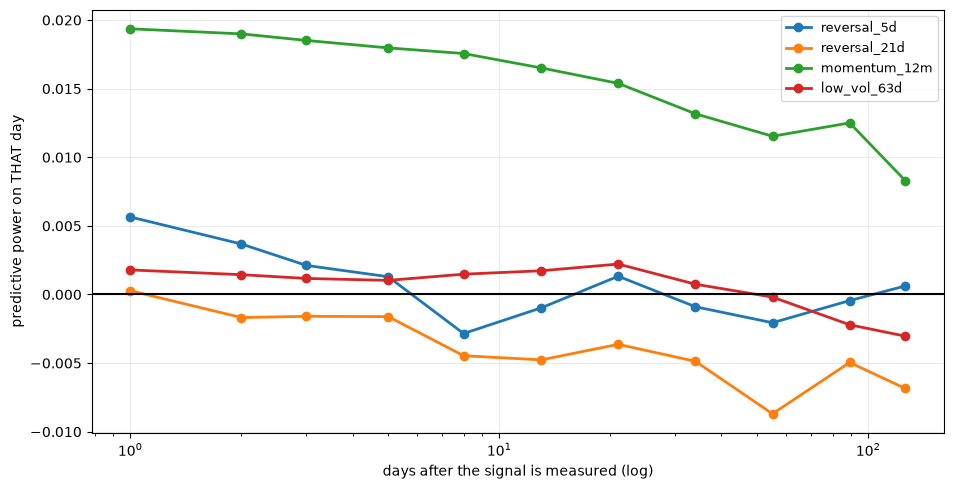

reversal_5d    half-life    57.4 days
reversal_21d   half-life     nan days
momentum_12m   half-life   113.7 days
low_vol_63d    half-life    71.0 days


In [3]:
profiles, cum = {}, {}
for name, s in sigs.items():
    d = st.lag_profile(s, R)
    if not d.empty:
        profiles[name] = d
        cum[name] = st.ic_decay(s, R, (1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 126, 252))
fig, ax = plt.subplots(figsize=(11, 5.5))
for name, d in profiles.items():
    ax.plot(d.index, d["ic"], "o-", lw=2, label=name)
ax.axhline(0, color="k", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("days after the signal is measured (log)")
ax.set_ylabel("predictive power on THAT day")
ax.legend(fontsize=9)
plt.show()
for name, d in profiles.items():
    f = st.fit_half_life(d)
    print(f"{name:14s} half-life {f.get('half_life', float('nan')):7.1f} days")

Reversal is nearly gone within days. Momentum and low volatility keep working for months. Those
are different businesses, and no Sharpe ratio distinguishes them.

## 2 · The mistake that makes everything look durable

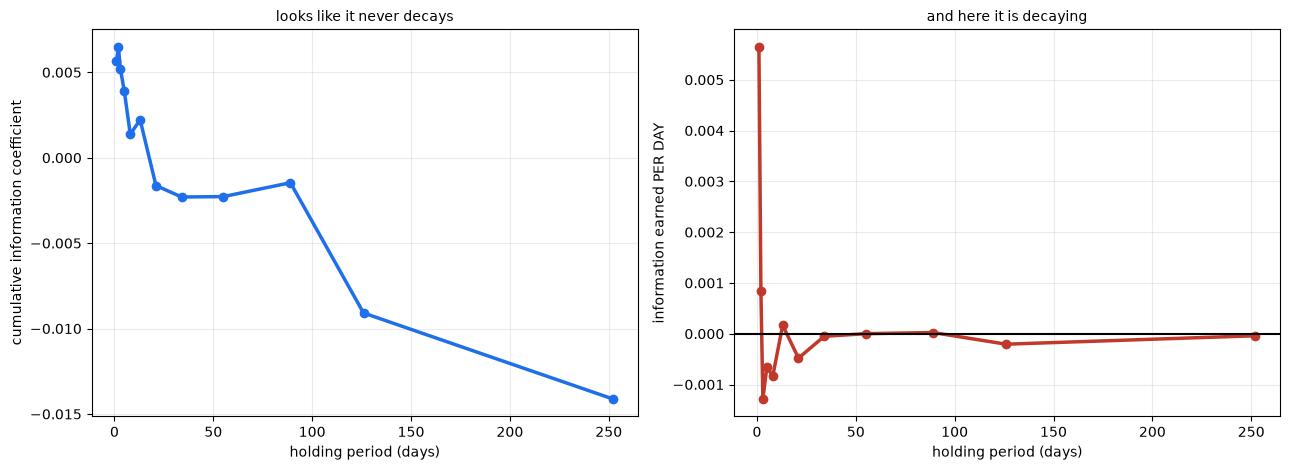

reversal_5d: cumulative IC rises from +0.0056 to -0.0141
        per-day IC falls from +0.00565 to -0.00004


In [4]:
name = min(profiles, key=lambda k: st.fit_half_life(profiles[k]).get(
    "half_life", np.inf))
d = cum[name]
m = st.marginal_ic(d)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index, d["ic"], "o-", lw=2.5, color="#1f6feb")
axes[0].set_xlabel("holding period (days)")
axes[0].set_ylabel("cumulative information coefficient")
axes[0].set_title("looks like it never decays", fontsize=10)
axes[1].plot(d.index, m["marginal_ic_per_day"], "o-", lw=2.5, color="#c0392b")
axes[1].axhline(0, color="k", lw=1.5)
axes[1].set_xlabel("holding period (days)")
axes[1].set_ylabel("information earned PER DAY")
axes[1].set_title("and here it is decaying", fontsize=10)
plt.tight_layout(); plt.show()
print(f"{name}: cumulative IC rises from {d['ic'].iloc[0]:+.4f} to {d['ic'].iloc[-1]:+.4f}")
print(f"        per-day IC falls from {m['marginal_ic_per_day'].iloc[0]:+.5f} to "
      f"{m['marginal_ic_per_day'].iloc[-1]:+.5f}")

Both panels are the same signal. Hold something longer and the *total* predicted return grows,
even as the signal itself dies. Fitting a decay curve to the left-hand chart would report every
strategy as far more patient than it is.

## 3 · How precisely do we know the number?

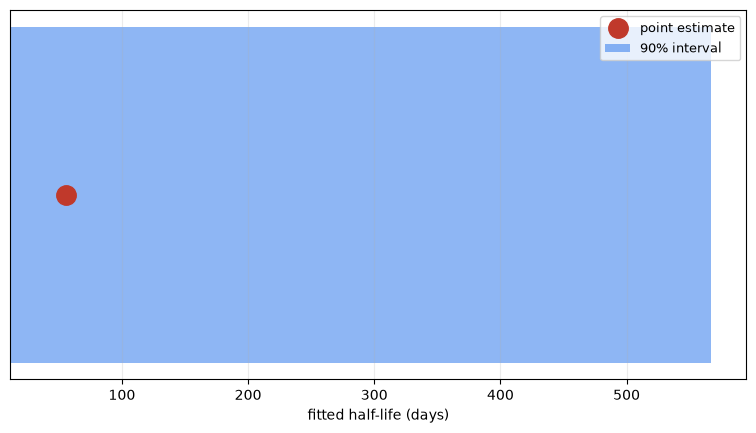

half-life: 55.4 days, but plausibly anywhere from 11.3 to 567.1
that is a factor of 50.2 between the ends of the interval


In [5]:
u = st.decay_uncertainty(sigs[name], R, n_boot=50)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh([0], [u["p95"] - u["p05"]], left=[u["p05"]], height=0.4, color="#1f6feb",
        alpha=0.5, label="90% interval")
ax.plot([u["median"]], [0], "o", ms=14, color="#c0392b", label="point estimate")
ax.set_yticks([]); ax.set_xlabel("fitted half-life (days)")
ax.legend(fontsize=9)
plt.show()
print(f"half-life: {u['median']:.1f} days, but plausibly anywhere from "
      f"{u['p05']:.1f} to {u['p95']:.1f}")
print(f"that is a factor of {u['ratio_95_05']:.1f} between the ends of the interval")

> \U0001F52C **For the quants.** This matters because the optimal trading rate is a smooth
> function of the half-life. Tuning it to three decimal places against an input known to within
> a factor of several is fitting noise with extra steps.

## 4 · So how often should you trade?

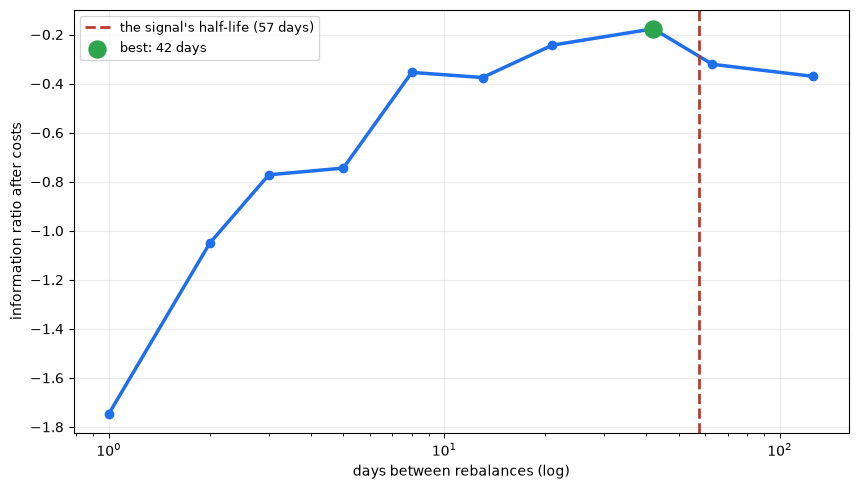

               ir  turnover_pa  cost_drag
rebalance                                
1         -1.7465     157.3742     0.1574
2         -1.0503     112.7597     0.1128
3         -0.7719      92.8041     0.0928
5         -0.7446      72.5537     0.0726
8         -0.3543      45.2710     0.0453
13        -0.3752      27.9077     0.0279
21        -0.2432      17.0709     0.0171
42        -0.1765       8.7008     0.0087
63        -0.3213       5.5744     0.0056
126       -0.3706       2.8927     0.0029


In [6]:
f = st.fit_half_life(profiles[name])
hl = f["half_life"]
rs = st.rebalance_sweep(sigs[name], R, hl,
                        periods=(1, 2, 3, 5, 8, 13, 21, 42, 63, 126), cost_bps=10.0)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(rs.index, rs["ir"], "o-", lw=2.5, color="#1f6feb")
ax.axvline(hl, color="#c0392b", lw=2, ls="--",
           label=f"the signal's half-life ({hl:.0f} days)")
best = rs["ir"].idxmax()
ax.scatter([best], [rs.loc[best, "ir"]], s=150, color="#2ea44f", zorder=5,
           label=f"best: {best} days")
ax.set_xscale("log"); ax.set_xlabel("days between rebalances (log)")
ax.set_ylabel("information ratio after costs"); ax.legend(fontsize=9)
plt.show()
print(rs[["ir", "turnover_pa", "cost_drag"]].round(4).to_string())

Trade much faster and you pay for a view that has not changed. Trade much slower and the view
has expired before you act on it. The peak sits near the half-life, which is the whole practical
point of measuring it.

## 5 · The formula everyone misuses

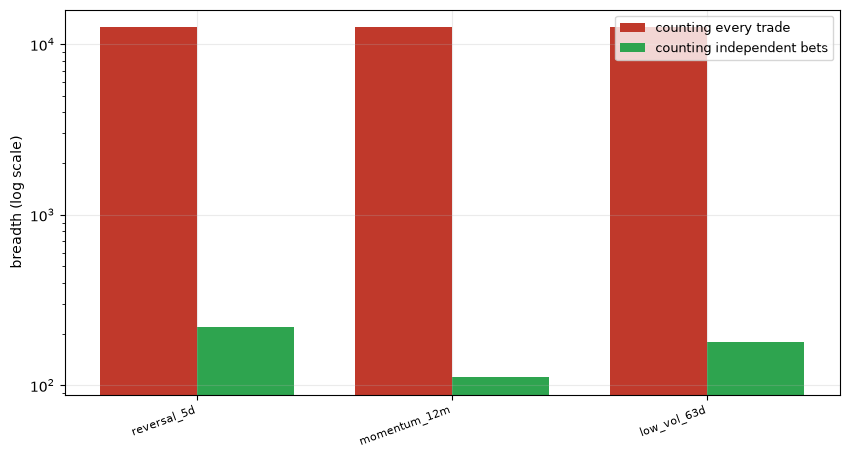

average raw correlation between these names:      0.388
average correlation after removing the market:    -0.016
              naive breadth  honest breadth  overstated by
signal                                                    
reversal_5d     12,600.0000        221.1000        57.0000
momentum_12m    12,600.0000        111.5000       113.0000
low_vol_63d     12,600.0000        180.0000        70.0000


In [7]:
resid = st._residual_correlation(R)
raw = R.corr().to_numpy()
raw_off = np.nanmean(raw[~np.eye(len(raw), dtype=bool)])
rows = []
for nm, pr in profiles.items():
    ff = st.fit_half_life(pr)
    h2 = ff.get("half_life", np.nan)
    if not np.isfinite(h2):
        continue
    b = st.effective_breadth(len(cols), int(max(h2, 1)), correlation=max(resid, 0))
    rows.append({"signal": nm, "naive breadth": b["naive_breadth"],
                 "honest breadth": b["breadth"], "overstated by": b["overstatement"]})
d2 = pd.DataFrame(rows).set_index("signal")
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(d2)); w = 0.38
ax.bar(x - w/2, d2["naive breadth"], w, color="#c0392b", label="counting every trade")
ax.bar(x + w/2, d2["honest breadth"], w, color="#2ea44f",
       label="counting independent bets")
ax.set_yscale("log"); ax.set_xticks(x)
ax.set_xticklabels(d2.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("breadth (log scale)"); ax.legend(fontsize=9)
plt.show()
print(f"average raw correlation between these names:      {raw_off:.3f}")
print(f"average correlation after removing the market:    {resid:.3f}")
print(d2.round(1).to_string())

Grinold's law says your information ratio is your skill times the square root of your breadth.
Counting breadth as "50 stocks × 252 days" is wrong twice over: a signal with a month-long
half-life gives you about twelve fresh views a year, not 252, and fifty correlated stocks are
not fifty independent bets.

## 6 · The verdict

**Signal: Weak.** Yes, and the differences are large. Measuring the rank information coefficient at every horizon from one day to a year across 50 names, the fitted half-lives ran from **57 days** (reversal_5d) to **114 days** (momentum_12m) — a factor of 2.0 between signals whose headline ICs differ by far less. That is the number that should appear beside a backtest and almost never does. Two measurement points are worth making. The fit is to the **marginal** IC, not the cumulative one: a cumulative IC can keep rising simply because the horizon is longer, which flatters every decay profile. And the half-life is estimated with real uncertainty — bootstrapping whole years of the panel puts a 90% interval of **8 to 566 days** on the headline signal, a ratio of 70.0×. Any formula that turns a half-life into a trading rate inherits that interval, which is a good reason not to tune one to three decimal places.

**Tradability: Useful.** Trading at roughly the decay rate wins, and the two ways of getting there agree. Sweeping the rebalancing period on reversal_5d at 10bp, the best information ratio came at **42 days** against a fitted half-life of 57 — 0.73× the half-life. Rebalancing 1× faster gave -1.75 and 126× slower gave -0.37, against -0.18 at the optimum. The Gârleanu-Pedersen partial-trading rule reaches the same place from the other direction: its closed form recommends trading 42% of the way each period, and the brute-force sweep put the optimum at 20%. Grinold's law is the piece that needs handling with care. Counting bets naively — 50 names × 252 days — gives a breadth of 12,600 and predicts an IR of -0.27. Correcting for the decay rate *and* for the -0.02 residual correlation between names brings breadth to 221 and the prediction to -0.04, against a realised -0.34. The naive count overstates breadth by **57×**, and since IR scales with its square root, that is a 8× exaggeration of the achievable information ratio.

## 7 · Going further \U0001F6AA

- **Measure the half-life before the Sharpe ratio.** It tells you the capacity, the cost
  tolerance and the rebalancing schedule, none of which a backtest headline conveys.
- **Trade partway, not all the way.** Gârleanu and Pedersen's result is that moving a fraction
  toward the target each period beats both full rebalancing and infrequent rebalancing. It is a
  one-line change to most systems.
- **Be suspicious of large claimed breadth.** If a manager's information ratio implies thousands
  of independent bets a year, ask what the signal's half-life is and how correlated the
  positions are. The two corrections in section 5 usually remove most of the claim.
- **The half-life shrinks after publication.** McLean and Pontiff (2016) found anomaly returns
  fall by about half once documented. Anything measured on historical data is an upper bound.